In [37]:
import ChiantiPy
import ChiantiPy.core as ch
import numpy as np
import matplotlib.pyplot as plt

In [71]:
temp = np.logspace(3, 5, 500) #K
dens = 5.4556e8 #cm^-3

#initialise the ion object
o2 = ch.ion('o_2', temperature=temp, eDensity=dens)

# Switch off collisional ionization
# Assume ionisation equilibrium for the element (Oxygen) to exist as purely O II ion at all temperature.
o2.IoneqOne = np.ones_like(temp)

# Compute the total bound-bound loss rate all lines
o2.boundBoundLoss(allLines=True)

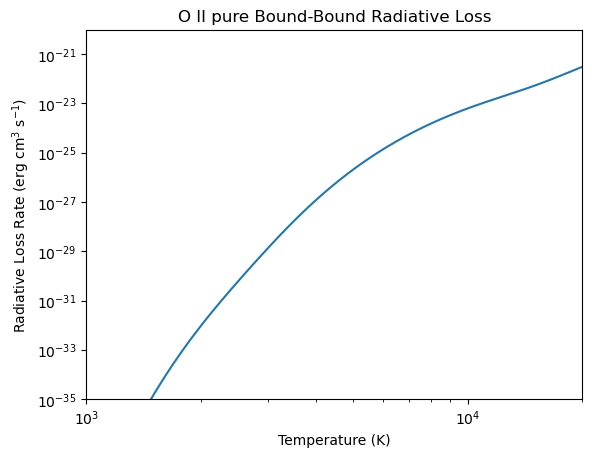

In [72]:
# Rescale from solar abundance to fully ionised abundance
plt.loglog(o2.BoundBoundLoss['temperature'], o2.BoundBoundLoss['rate']/o2.Abundance)
plt.ylim(1e-35, 1e-20)
plt.xlim(1e3, 2e4)
plt.ylabel('Radiative Loss Rate (erg cm$^3$ s$^{-1}$)')
plt.xlabel('Temperature (K)')
plt.title('O II pure Bound-Bound Radiative Loss')
plt.show()

# For different lines

In [73]:
o2.intensity() #ergs cm^-3 s^-1 str^-1
o2.intensityList(index=250, top=30)

 wvlRange should be specified
using index =   250 specifying temperature =    1.00e+04
   
 ------------------------------------------
   
  Ion  lvl1  lvl2                     lower -                     upper      Wvl (Å)    Intensity      A value Obs
  o_2     1    13             2s2 2p3 4S1.5 - 2s2 2p2 3s 4P2.5              539.0860     1.28e-34     8.77e+08 Y
  o_2     1    12             2s2 2p3 4S1.5 - 2s2 2p2 3s 4P1.5              539.5470     9.38e-35     8.77e+08 Y
  o_2     1    11             2s2 2p3 4S1.5 - 2s2 2p2 3s 4P0.5              539.8540     4.68e-35     8.77e+08 Y
  o_2     3    15             2s2 2p3 2D2.5 - 2s2 2p2 3s 2P1.5              616.3040     6.89e-35     2.85e+09 Y
  o_2     2    15             2s2 2p3 2D1.5 - 2s2 2p2 3s 2P1.5              616.3790     7.11e-36     2.94e+08 Y
  o_2     2    14             2s2 2p3 2D1.5 - 2s2 2p2 3s 2P0.5              617.0630     3.95e-35     3.18e+09 Y
  o_2     5    16             2s2 2p3 2P1.5 - 2s 2p4 2S0.5          

using index =   250 specifying temperature =    1.00e+04


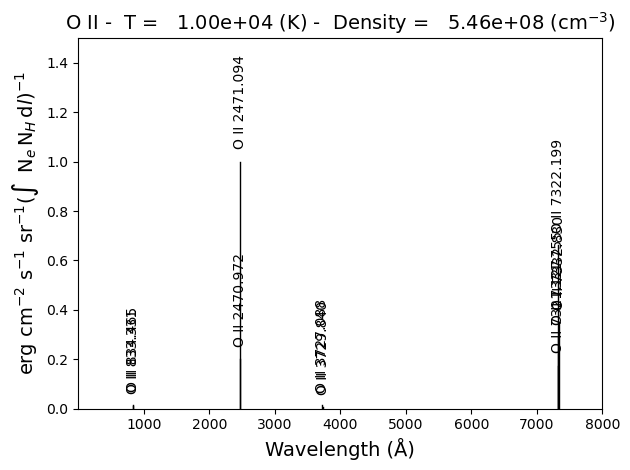

In [74]:
# Most dominant lines in the O II can be identified using the following
o2.intensityPlot(wvlRange=[1.,8000], relative=True)

## C2

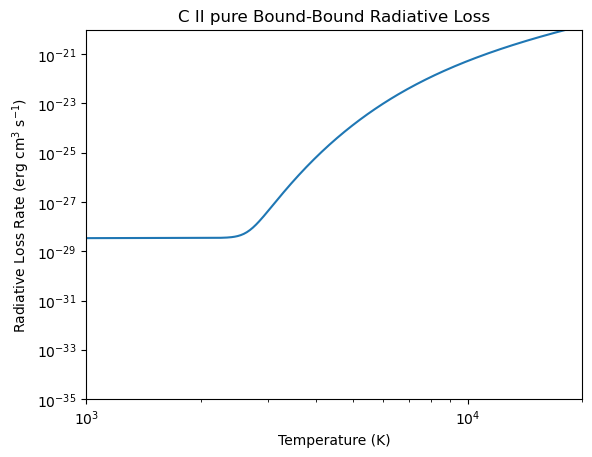

In [75]:
temp = np.logspace(3, 5, 500) #K
dens = 5.4556e8 #cm^-3

#initialise the ion object
c2 = ch.ion('c_2', temperature=temp, eDensity=dens)

# Switch off collisional ionization
# Assume ionisation equilibrium for the element (Oxygen) to exist as purely O II ion at all temperature.
c2.IoneqOne = np.ones_like(temp)

# Compute the total bound-bound loss rate all lines
c2.boundBoundLoss(allLines=True)

# Rescale from solar abundance to fully ionised abundance
plt.loglog(c2.BoundBoundLoss['temperature'], c2.BoundBoundLoss['rate']/c2.Abundance)
plt.ylim(1e-35, 1e-20)
plt.xlim(1e3, 2e4)
plt.ylabel('Radiative Loss Rate (erg cm$^{3}$ s$^{-1}$)')
plt.xlabel('Temperature (K)')
plt.title('C II pure Bound-Bound Radiative Loss')
plt.show()

In [76]:
c2.intensity() #ergs cm^-3 s^-1 str^-1
# c2.intensityList(index=250, top=30)
c2.intensityList(wvlRange=[1e6, 2e6], top=50)

using index =   250 specifying temperature =    1.00e+04
   
 ------------------------------------------
   
  Ion  lvl1  lvl2                     lower -                     upper      Wvl (Å)    Intensity      A value Obs
  c_2   202   203              2p2 3p 2P1.5 - 2p2 3d 2D2.5              1064894.6800     5.31e-50     3.17e+07 N
  c_2     1     2              2s2 2p 2P0.5 - 2s2 2p 2P1.5              1577361.7000     7.52e-34     2.29e-06 Y
   
 ------------------------------------------
   


using index =   250 specifying temperature =    1.00e+04


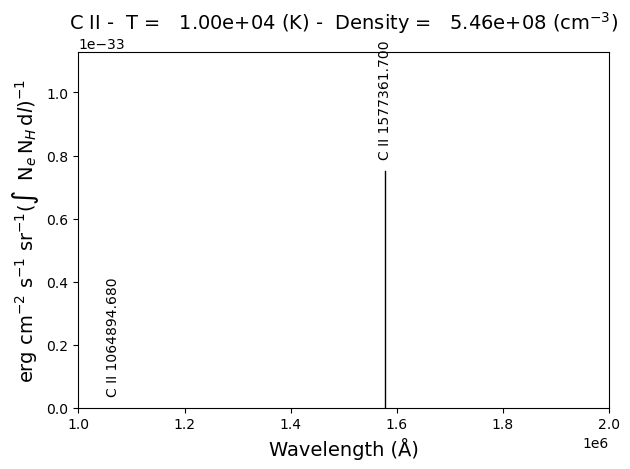

In [77]:
# Most dominant lines in the C II can be identified using the following
c2.intensityPlot(wvlRange=[1e6,2e6])

# How does ne affect cooling rate?

<>:5: SyntaxWarning: "\A" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\A"? A raw string is also an option.
<>:33: SyntaxWarning: "\A" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\A"? A raw string is also an option.
<>:5: SyntaxWarning: "\A" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\A"? A raw string is also an option.
<>:33: SyntaxWarning: "\A" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\A"? A raw string is also an option.
/var/folders/nd/pn3mw1xj703gtgppx79rsh0c0000gn/T/ipykernel_19224/3385527058.py:5: SyntaxWarning: "\A" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\A"? A raw string is also an option.
  bands = {'3727 $\AA$': (3720, 3735)}
/var/folders/nd/pn3mw1xj703gtgppx79rsh0c0000gn/T/ipykernel_19224/3385527058.py:33: SyntaxWarning: "\A" is an invalid e

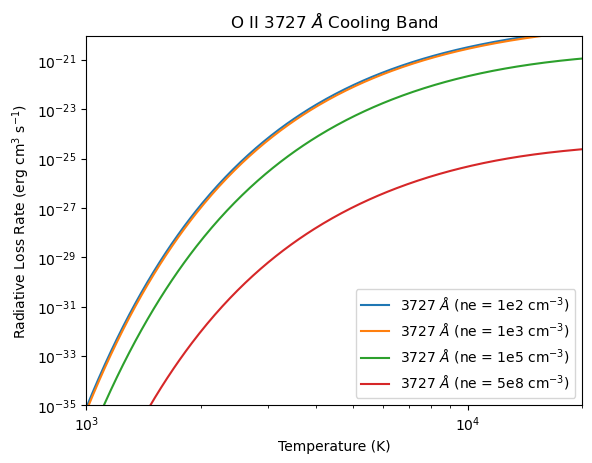

In [78]:
temp = np.logspace(3, 5, 500)
densities = [1e2, 1e3, 1e5, 5e8]  
density_labels = ['1e2', '1e3', '1e5', '5e8'] 

bands = {'3727 $\AA$': (3720, 3735)}

plt.figure()

# Loop through the set of free electron densities
for dens, dens_label in zip(densities, density_labels):
    
    # 1. Initialize ion for this specific density
    o_2 = ch.ion('o_2', temperature=temp, eDensity=dens)
    o_2.IoneqOne = np.ones_like(temp)
    o_2.intensity()

    # 2. Extract wavelengths and pure cooling rates
    wvl = o_2.Intensity['wvl']
    line_cooling = o_2.Intensity['intensity'] * 4 * np.pi / o_2.Abundance

    # 3. Sum the multiplet and plot
    for band_name, (w_min, w_max) in bands.items():
        band_indices = np.where((wvl >= w_min) & (wvl <= w_max))[0]
        
        if len(band_indices) > 0:
            total_band_cooling = np.sum(line_cooling[:, band_indices], axis=1)
            
            # Plot with a label that includes the density
            plt.loglog(temp, total_band_cooling, label=f"{band_name} (ne = {dens_label} cm$^{{-3}}$)")

plt.xlabel('Temperature (K)')
plt.ylabel('Radiative Loss Rate (erg cm$^{3}$ s$^{-1}$)')
plt.title('O II 3727 $\AA$ Cooling Band')
plt.ylim(1e-35, 1e-20)
plt.xlim(1e3, 2e4)
plt.legend()
plt.show()

# Need know how to identify the most relavant lines

In [33]:
temp = np.logspace(3, 5, 500)
dens = 5.4556e8

# 1. Initialize and calculate all lines
o_2 = ch.ion('o_2', temperature=temp, eDensity=dens)
o_2.IoneqOne = np.ones_like(temp)
o_2.intensity()

wvl = o_2.Intensity['wvl']
line_cooling = o_2.Intensity['intensity'] * 4 * np.pi / o_2.Abundance

# 2. Pick the temperature to evaluate the dominance (e.g., 10^4 K)
target_idx = 250 
rates_at_target = line_cooling[target_idx, :]

# # Sort all transition indices from highest cooling rate to lowest
# sorted_indices = np.argsort(rates_at_target)[::-1]

# # 3. Dynamic Clustering Algorithm
# top_bands = []
# used_indices = set()
# tolerance = 10.0  # Search window in Angstroms (groups lines within +/- 10 Å)

# for idx in sorted_indices:
#     # Skip if we already grouped this line into a previous multiplet
#     if idx in used_indices:
#         continue
        
#     center_wvl = wvl[idx]
    
#     # Find all lines within the tolerance window of this dominant line
#     band_indices = np.where(np.abs(wvl - center_wvl) <= tolerance)[0]
    
#     # Mark these lines as 'grouped' so they aren't double-counted later
#     used_indices.update(band_indices)
    
#     # Sum the cooling rates of this entire multiplet across all temperatures
#     total_band_cooling = np.sum(line_cooling[:, band_indices], axis=1)
    
#     # Store the result
#     top_bands.append({
#         'label': f"~{center_wvl:.0f} $\AA$ Band",
#         'cooling_array': total_band_cooling
#     })
    
#     # Stop once we have identified the top 4 bands
#     if len(top_bands) >= 4:
#         break

# # 4. Plot the dynamically identified bands
# plt.figure()

# for band in top_bands:
#     plt.loglog(temp, band['cooling_array'], label=band['label'])

# plt.xlabel('Temperature (K)')
# plt.ylabel('Radiative Loss Rate (erg cm$^3$ s$^{-1}$)')
# plt.title('Top 4 O II Cooling Bands (Dynamically Identified)')
# plt.ylim(1e-35, 1e-20)
# plt.legend()
# plt.show()

In [35]:
temp = np.logspace(3, 5, 500)
dens = 5.4556e8

# 1. Initialize and calculate all lines
o_2 = ch.ion('o_2', temperature=temp, eDensity=dens)
o_2.IoneqOne = np.ones_like(temp)
o_2.intensity()

wvl = o_2.Intensity['wvl']
line_cooling = o_2.Intensity['intensity'] * 4 * np.pi / o_2.Abundance

# # 2. Pick the temperature to evaluate the dominance (e.g., 10^4 K)
# target_idx = 250 
# rates_at_target = line_cooling[target_idx, :]